# Observability and trajectory stability

Raw daily-accuracy slopes are not stable enough to freeze `FutureObservable`. Within the 945-student prediction population, a 7–14 slope has weak convergence with the full 7–31 slope (Spearman 0.256; 61.5% sign agreement); 7–21 improves to 0.574 and 71.6%. Yet only about 18% of full-window slopes have a 95% interval that excludes zero, even among students with at least 14 evaluated active days. We therefore retain `FutureActive` as a settled definition but defer the trajectory-observability threshold until the partially pooled, difficulty-adjusted measurement model is available.

## Context & Methods

We evaluate how much future temporal coverage is needed to estimate a stable trajectory. `FutureActive` means at least one event in `[7, 31)`; `FutureObservable` means enough distinct active days to estimate a slope. The outcome used here is an exploratory raw daily-accuracy slope, not the final difficulty-adjusted target.

### Key Assumptions

- Daily accuracy is calculated from summed successes and denominators, never as an average of event rates.
- Each active day receives equal weight in the exploratory slope.
- At least three days containing evaluated performance are required to fit a slope and estimate its standard error.
- Comparisons with `[7, 31)` measure convergence, not independent validation, because shorter windows overlap the full window.
- Exact raw duplicates remain included; their impact will be assessed separately.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.trajectory_stability import (
    aggregate_daily_performance,
    compare_to_full_window,
    estimate_all_windows,
    stability_by_minimum_days,
)

sns.set_theme(style='whitegrid', context='notebook')
COLORS = {'primary': '#2457A6', 'comparison': '#D18F00', 'neutral': '#6B7280'}
EVENTS_PATH = PROJECT_ROOT / 'data/interim/events_clean.parquet'
COVERAGE_PATH = PROJECT_ROOT / 'data/interim/student_coverage.parquet'

## Data

Load audited artifacts and verify their expected grains.

In [2]:
events = pd.read_parquet(EVENTS_PATH)
coverage = pd.read_parquet(COVERAGE_PATH)
assert len(events) == 415_461
assert coverage['user_id'].is_unique and len(coverage) == 1_000

initial_cohort = coverage.loc[coverage['initial_eligible'], 'user_id']
daily = aggregate_daily_performance(events.loc[events['user_id'].isin(initial_cohort)])
print(f'Event rows: {len(events):,}')
print(f'Students in coverage: {len(coverage):,}')
print(f'Initially eligible students: {len(initial_cohort):,}')
print(f'Student-days with evaluated future content in the initial cohort: {len(daily):,}')

Event rows: 415,461
Students in coverage: 1,000
Initially eligible students: 945
Student-days with evaluated future content in the initial cohort: 8,582


## Results

### 1. Future activity coverage

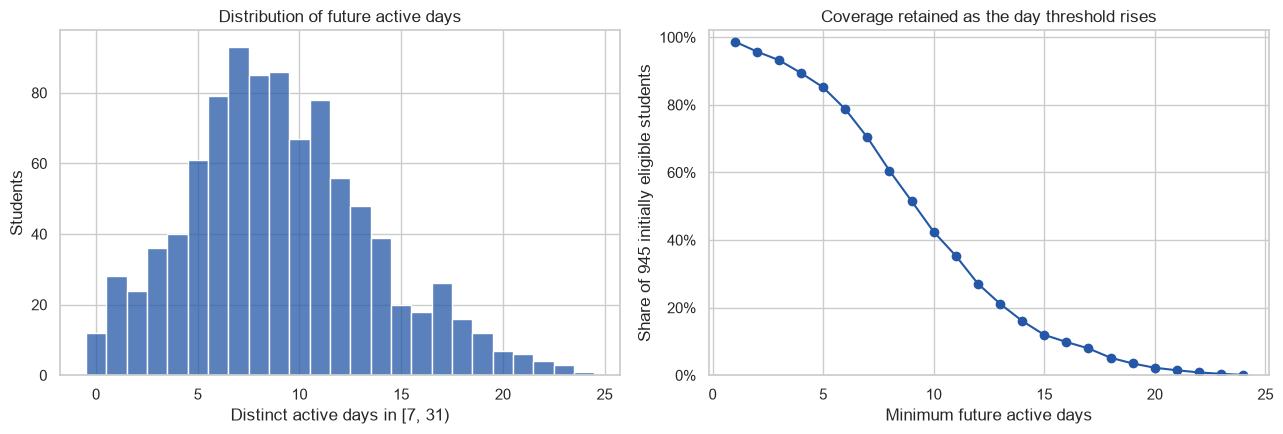

In [3]:
prediction_coverage = coverage.loc[coverage['initial_eligible']].copy()
future_days = prediction_coverage['future_days_active']
thresholds = np.arange(1, int(future_days.max()) + 1)
survival = pd.DataFrame({
    'minimum_active_days': thresholds,
    'students': [(future_days >= threshold).sum() for threshold in thresholds],
})
survival['share_initial_cohort'] = survival['students'] / len(prediction_coverage)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(future_days, discrete=True, ax=axes[0], color=COLORS['primary'])
axes[0].set(title='Distribution of future active days', xlabel='Distinct active days in [7, 31)', ylabel='Students')
axes[1].plot(survival['minimum_active_days'], survival['share_initial_cohort'], marker='o', color=COLORS['primary'])
axes[1].set(title='Coverage retained as the day threshold rises', xlabel='Minimum future active days', ylabel='Share of 945 initially eligible students', ylim=(0, 1.02))
axes[1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout();

### 2. Convergence of truncated-window slopes

Short-window slopes are compared with `[7, 31)`. Because windows overlap, these correlations are optimistic diagnostics rather than out-of-sample reliability estimates.

In [4]:
window_estimates = estimate_all_windows(daily, min_active_days=3)
window_comparison = compare_to_full_window(window_estimates)
window_comparison.round(4)

,window,students,pearson,spearman,sign_agreement,mae_vs_full
0,days_7_14,600,0.3904,0.2562,0.6150,0.0235
1,days_7_21,797,0.5939,0.5736,0.7164,0.0092
2,days_7_31,880,1.0000,1.0000,1.0000,0.0000


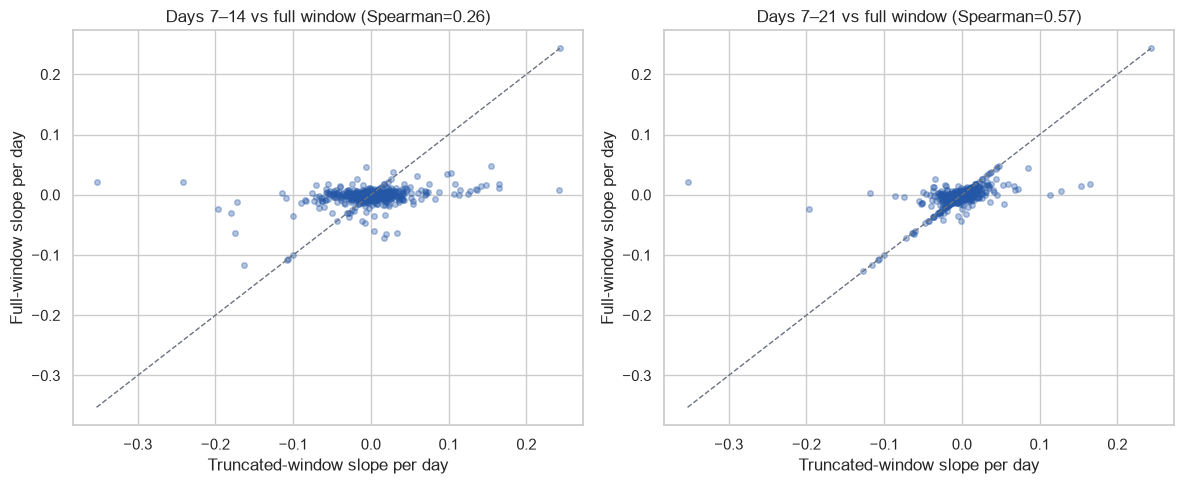

In [5]:
full = window_estimates['days_7_31'][['user_id', 'slope']].rename(columns={'slope': 'full_slope'})
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)
for axis, name, title in zip(axes, ['days_7_14', 'days_7_21'], ['Days 7–14', 'Days 7–21']):
    comparison = window_estimates[name][['user_id', 'slope']].merge(full, on='user_id')
    axis.scatter(comparison['slope'], comparison['full_slope'], s=16, alpha=0.35, color=COLORS['primary'])
    limits = [min(comparison[['slope', 'full_slope']].min()), max(comparison[['slope', 'full_slope']].max())]
    axis.plot(limits, limits, linestyle='--', color=COLORS['neutral'], linewidth=1)
    rho = comparison['slope'].rank().corr(comparison['full_slope'].rank())
    axis.set(title=f'{title} vs full window (Spearman={rho:.2f})', xlabel='Truncated-window slope per day', ylabel='Full-window slope per day')
plt.tight_layout();

### 3. Uncertainty as minimum active-day coverage increases

In [6]:
stability = stability_by_minimum_days(daily)
stability.round(5)

,min_active_days,students,median_slope_se,median_ci_width,resolved_sign_rate,median_r_squared
0,3,880,0.00417,0.01636,0.18182,0.11579
1,4,845,0.00413,0.01617,0.17870,0.10995
2,5,805,0.00405,0.01587,0.17888,0.10454
3,7,665,0.00379,0.01486,0.17895,0.08543
4,10,400,0.00342,0.01341,0.17750,0.07436
5,14,152,0.00294,0.01151,0.17763,0.06000


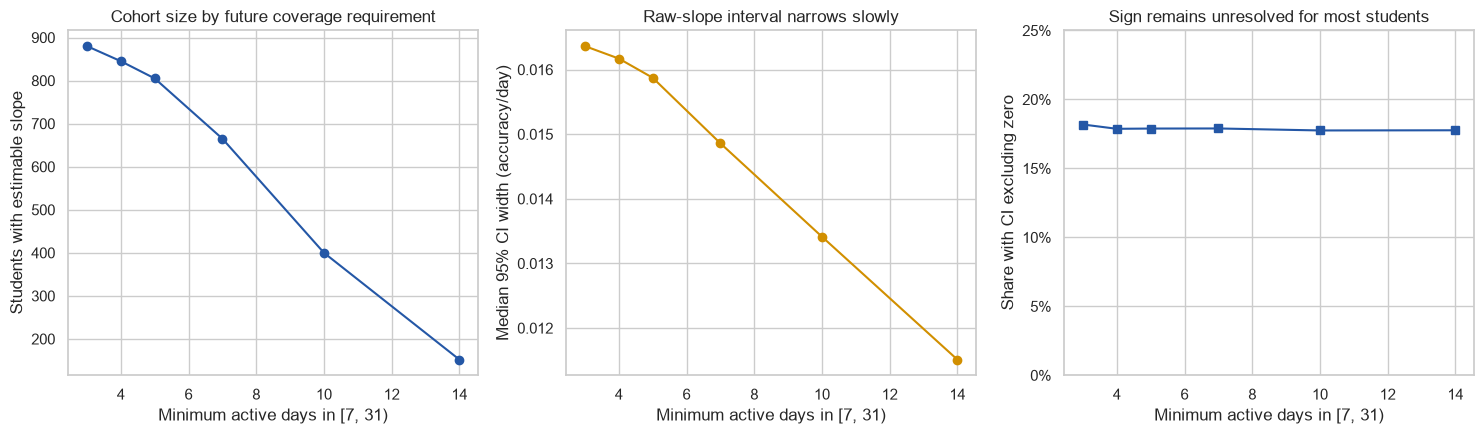

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(stability['min_active_days'], stability['students'], marker='o', color=COLORS['primary'])
axes[0].set(title='Cohort size by future coverage requirement', xlabel='Minimum active days in [7, 31)', ylabel='Students with estimable slope')
axes[1].plot(stability['min_active_days'], stability['median_ci_width'], marker='o', color=COLORS['comparison'])
axes[1].set(title='Raw-slope interval narrows slowly', xlabel='Minimum active days in [7, 31)', ylabel='Median 95% CI width (accuracy/day)')
axes[2].plot(stability['min_active_days'], stability['resolved_sign_rate'], marker='s', color=COLORS['primary'])
axes[2].set(title='Sign remains unresolved for most students', xlabel='Minimum active days in [7, 31)', ylabel='Share with CI excluding zero', ylim=(0, 0.25))
axes[2].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout();

## Takeaways

- `FutureActive` is well defined as any event in `[7, 31)`.
- Three future days containing evaluated performance are mathematically sufficient to fit a slope, but not sufficient evidence that the slope is reliable.
- Extending the truncated window from 7–14 to 7–21 materially improves convergence with the full-window slope, while sign agreement remains only 71.7%.
- Requiring more evaluated active days reduces the cohort sharply (880 at 3 days; 665 at 7; 152 at 14) but leaves the resolved-sign rate near 18%.
- Therefore no raw-accuracy-based threshold is frozen. The next measurement-model phase must use partial pooling and content adjustment; observability will then be selected from posterior/interval precision and coverage.